## Text Splitting in LLM-based Applications

### What is Text Splitting?

Text splitting is the process of breaking a large piece of text into smaller, manageable chunks so that it can be processed effectively by language models.

Large sources such as:
- PDFs with hundreds or thousands of pages  
- Long text files  
- Books, articles, or HTML pages  

are difficult for LLMs to handle as a single input.  
Text splitting solves this by dividing the content into smaller units called **chunks**.

A **Text Splitter** is the component responsible for performing this operation.

---

## Why Text Splitting is Important

### 1. Context Length Limitations of LLMs

Every LLM has a maximum input size (context length).

- If a model supports only a fixed number of tokens,
- Large documents can easily exceed this limit,
- Making direct processing impossible.

**Text splitting allows large documents to be processed incrementally without exceeding model limits.**

---

### 2. Better Performance in Downstream Tasks

LLM-based systems perform several downstream tasks such as:
- Embeddings
- Semantic search
- Summarization

Text splitting improves results across all of these tasks.

#### a. Better Embeddings Quality

- Embeddings convert text into numerical vectors.
- Very large texts produce embeddings that fail to capture precise semantic meaning.
- Smaller chunks preserve focused context and meaning.

**Example intuition:**
- One paragraph discussing a single topic → better semantic representation
- Entire document covering many topics → diluted embedding

---

#### b. Improved Semantic Search

Semantic search works by:
- Comparing query embeddings with document embeddings
- Finding the most similar content

Chunked documents:
- Allow more precise matching
- Reduce irrelevant retrieval
- Improve answer accuracy

---

#### c. More Reliable Summarization

When summarizing very large texts:
- Models may drift off-topic
- Hallucinate missing information
- Produce vague summaries

Chunk-wise summarization:
- Keeps context focused
- Produces grounded and consistent summaries
- Can be combined later into a final summary

---

### 3. Computational Efficiency

Working with smaller chunks provides:
- Lower memory usage
- Reduced compute cost
- Easier parallel processing

This makes systems:
- Faster
- More scalable
- More cost-efficient

---

## Types of Text Splitting Strategies

In practice, text can be split in multiple ways depending on the use case.

### 1. Length-based Splitting
- Splits text based on character count or token count
- Simple and widely used
- Useful when structure is unknown

---

### 2. Text Structure-based Splitting
- Splits based on paragraphs, sentences, or separators
- Preserves natural language flow
- Useful for articles and essays

---

### 3. Document Structure-based Splitting
- Splits based on sections like:
  - Pages
  - Headings
  - Chapters
- Useful for PDFs, reports, and manuals

---

### 4. Semantic-based Splitting
- Splits text based on meaning rather than length
- Keeps semantically related content together
- Produces highest-quality chunks for retrieval and embeddings

---

## Key Takeaway

Text splitting is a foundational step in building robust LLM and RAG-based systems.

It:
- Overcomes model limitations
- Improves accuracy
- Enhances performance across embeddings, search, and summarization
- Optimizes computational resources

Understanding and choosing the right splitting strategy is critical for production-grade applications.


## Length-Based Text Splitting

### What is Length-Based Text Splitting?

Length-based text splitting is the simplest and fastest technique for splitting large text into smaller chunks.

In this approach:
- You **predefine the size of each chunk**
- The splitter moves through the text sequentially
- Once the defined length is reached, a chunk is created
- The process continues until the entire text is split

The chunk size can be defined using:
- **Characters**
- **Tokens**

---

## How Length-Based Splitting Works (Intuition)

Assume:
- You have a long text with multiple paragraphs
- You decide that **each chunk should be 100 characters**

### Step-by-step process:
1. Start reading the text from the beginning
2. Count characters until you reach 100
3. Create **Chunk 1**
4. Resume from the exact point where you stopped
5. Repeat the same process for the next 100 characters
6. Continue until the full text is consumed
7. Any remaining text becomes the final chunk

This results in multiple fixed-size chunks like:
- Chunk 1 → first 100 characters
- Chunk 2 → next 100 characters
- Chunk 3 → next 100 characters
- …
- Last chunk → remaining characters

The same logic applies if you choose **tokens instead of characters**.

---

## Key Characteristics

- Chunk size is **fixed**
- Splitting is **purely positional**
- No understanding of language or meaning is involved

---

## Advantages of Length-Based Splitting

### 1. Conceptually Very Simple
- Easy to understand
- No complex rules or configurations

### 2. Fast Execution
- Requires minimal computation
- Works well for large volumes of text

### 3. Easy to Implement
- Supported out-of-the-box in most frameworks
- Useful for quick prototypes and experiments

---

## Limitations of Length-Based Splitting

### 1. Ignores Linguistic Structure
The splitter does **not** consider:
- Sentence boundaries
- Word boundaries
- Paragraph structure
- Grammar rules

As a result:
- Words can be cut in the middle
- Sentences can be broken abruptly
- Paragraphs may be split halfway

---

### 2. Ignores Semantic Meaning

This is the biggest drawback.

**Why it matters:**
- A single topic or idea may get split across two chunks
- Each chunk contains incomplete information
- Downstream tasks suffer in quality

---

### Impact on Embeddings (Example)

Imagine:
- A paragraph fully explaining one concept
- The paragraph gets split into two chunks mid-way

Now:
- Chunk 1 contains half the idea
- Chunk 2 contains the remaining half
- Neither chunk fully represents the semantic meaning

As a result:
- Embeddings become weaker
- Semantic search accuracy drops
- Retrieval quality degrades

---

## When to Use Length-Based Splitting

This method is suitable when:
- Speed is more important than accuracy
- Text structure is not important
- You are building quick experiments or demos
- You plan to apply additional processing later

---

## When to Avoid It

Avoid length-based splitting when:
- Semantic understanding is critical
- You are building production-grade RAG systems
- High-quality embeddings and retrieval are required
- Document structure matters

---

## Summary

Length-based text splitting:
- Is the **simplest and fastest** splitting strategy
- Works purely on fixed-size chunks
- Ignores grammar, structure, and meaning

It is useful for quick workflows but is usually **not ideal for high-quality LLM or RAG applications**.


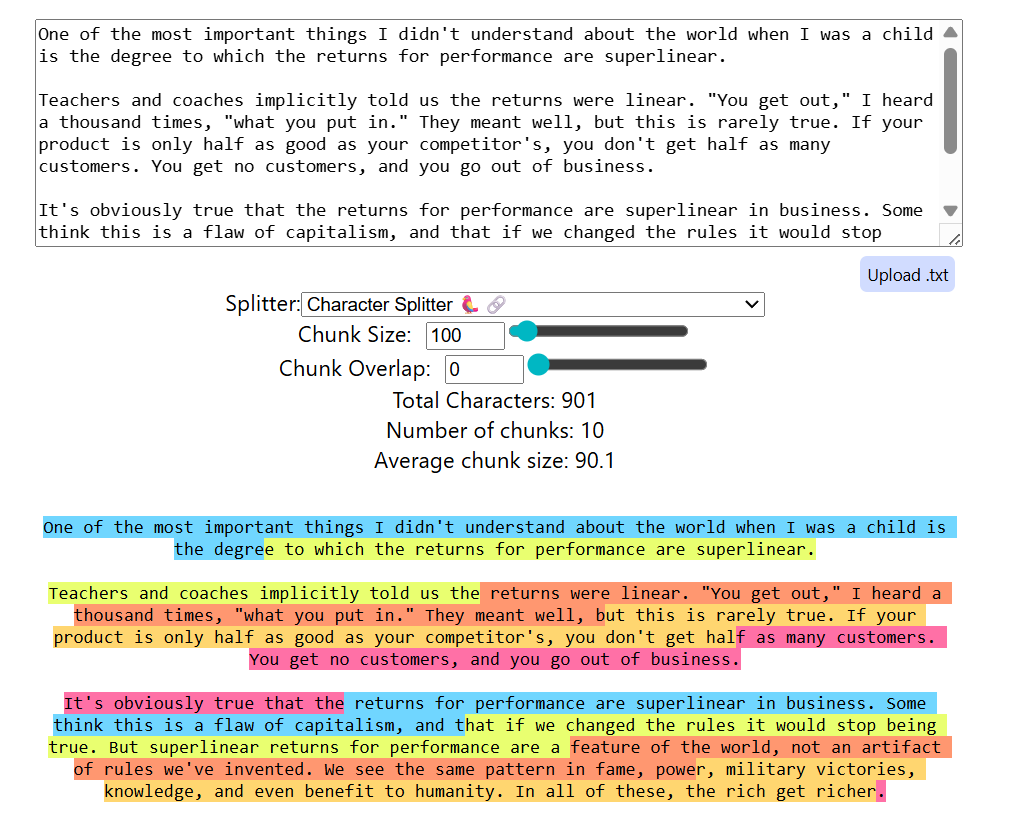

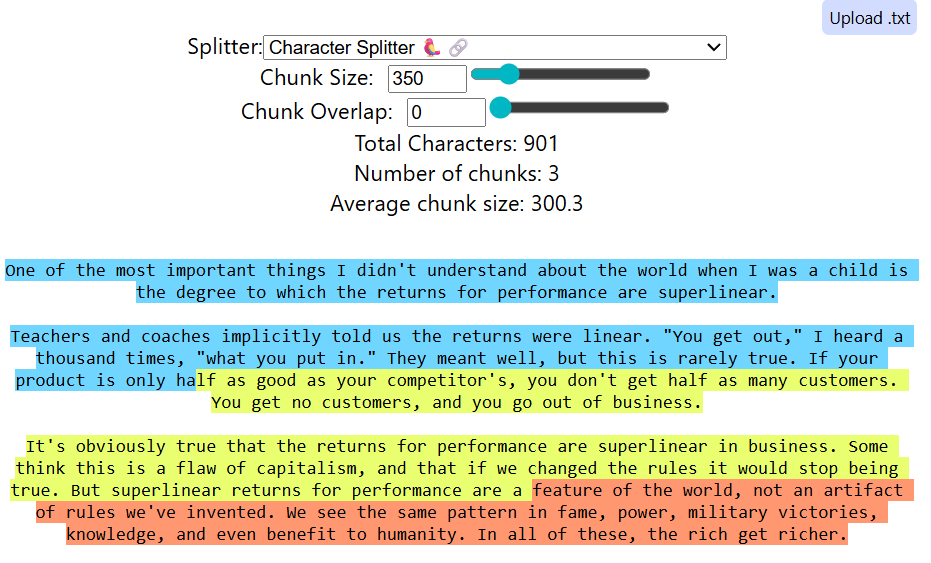

In [8]:
from langchain.text_splitter import CharacterTextSplitter
from langchain_community.document_loaders import PyPDFLoader

loader = PyPDFLoader('Machine Learning Test.pdf')

docs = loader.load()

splitter = CharacterTextSplitter(
    chunk_size=200,
    chunk_overlap=0,
    separator=''
)

result = splitter.split_documents(docs)

In [9]:
print(result[0].page_content)

Machine Learning Test 
❖ Read Carefully Multiple Options could be correct  
 
1. In the context of machine learning, the ability to extract patterns from data relies on distinct 
learning paradigms. I


## Chunk Overlap in Text Splitting

### What is Chunk Overlap?

Chunk overlap defines **how many characters (or tokens) are shared between two consecutive chunks** during text splitting.

In simple terms:
- Chunk overlap controls **how much previous context is repeated** in the next chunk
- The overlapping portion appears in **both chunks**

---

## Understanding Chunk Overlap with Intuition

Assume:
- Chunk size = **100 characters**
- Chunk overlap = **5 characters**

### What happens?
- Chunk 1 → characters 1 to 100
- Chunk 2 → characters **96 to 195**

The last **5 characters of Chunk 1** are repeated at the start of **Chunk 2**.

This repeated section is called the **overlapping region**.

---

## Visual Interpretation (Conceptual)

- Blue chunk → first chunk
- Yellow chunk → second chunk
- The overlapping region sits **between them**
- Increasing chunk overlap increases the size of this shared region

---

## Why Do We Need Chunk Overlap?

Earlier, we discussed a major drawback of length-based splitting:

- Text can be cut **abruptly**
- Words, sentences, or ideas may break in the middle
- Context may be lost across chunks

### This creates problems especially for:
- Embeddings
- Semantic search
- RAG (Retrieval-Augmented Generation)

Chunk overlap helps **reduce context loss**.

---

## Core Idea Behind Chunk Overlap

The main goal is:

> To ensure that important context is **not lost when text is split abruptly**

By slightly repeating content:
- Information that was cut at the boundary is still available
- Context flows smoothly from one chunk to the next
- The model gets better semantic continuity

---

## How Chunk Overlap Helps Embeddings

Without overlap:
- One idea may get split into two chunks
- Each chunk holds incomplete meaning

With overlap:
- Key context appears in both chunks
- Embeddings capture meaning more accurately
- Retrieval quality improves

---

## Trade-Off: Overlap vs Performance

Chunk overlap is powerful, but it comes with a cost.

### Increasing overlap:
✅ Better context retention  
❌ More chunks generated  
❌ Higher computation cost  
❌ More embeddings to store and process  

### Decreasing overlap:
✅ Faster processing  
❌ Higher risk of context loss  

This is a **classic trade-off** between quality and efficiency.

---

## What is a Good Chunk Overlap Value?

A commonly used rule of thumb (especially for RAG systems):

- **10–20% of chunk size**

### Examples:
- Chunk size = 100 → overlap = 10–20
- Chunk size = 500 → overlap = 50–100
- Chunk size = 1000 → overlap = 100–200

There is no single perfect number — it depends on:
- Text complexity
- Importance of context
- Performance constraints

---

## When Chunk Overlap is Especially Important

Chunk overlap is highly recommended when:
- You are building RAG-based applications
- Semantic understanding matters
- Documents contain long explanations
- Context continuity is critical

---

## Summary

- Chunk overlap controls **shared content between chunks**
- It helps retain context lost due to abrupt splitting
- Improves embedding and retrieval quality
- Too much overlap increases computation
- A balanced overlap (10–20%) works well in practice

Chunk overlap turns a **naive splitter** into a **more context-aware splitter**.


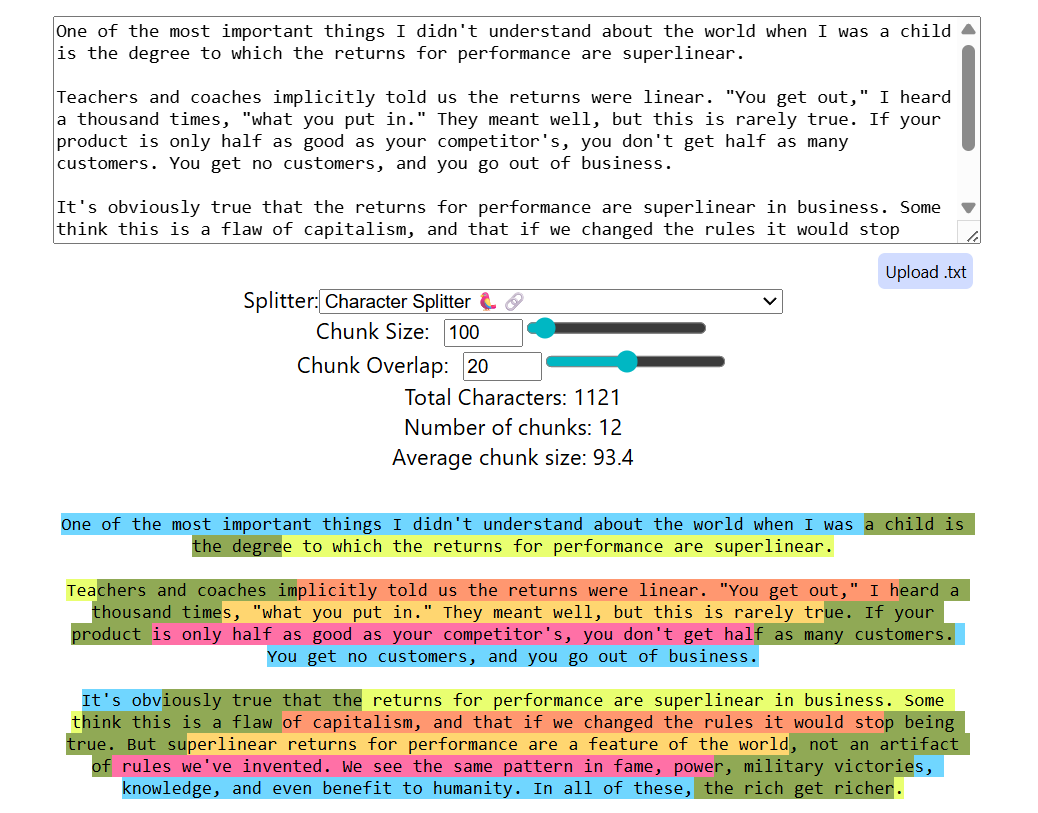

## Text Structure–Based Text Splitting  
### (Recursive Character Text Splitting)

### Core Idea

Text is **not random**.  
It naturally follows a structure:

- Paragraphs  
- Sentences  
- Words  
- Characters  

Text structure–based splitting **respects this hierarchy** instead of cutting text abruptly.

This is exactly what **Recursive Character Text Splitting** does.

---

## Why This Technique Exists

Length-based splitting is:
- Fast
- Simple  
But it **ignores meaning, grammar, and structure**

Recursive Character Text Splitting was designed to:
- Preserve linguistic structure as much as possible
- Avoid cutting words or sentences mid-way
- Still respect a fixed maximum chunk size

That’s why it is **one of the most widely used splitters in LangChain**.

---

## How Recursive Character Text Splitting Works

This splitter works **top-down**, using a list of separators.

### Common Separator Hierarchy

In order of priority:

1. `\n\n` → Paragraphs  
2. `\n` → Sentences / lines  
3. `" "` → Words  
4. `""` → Characters (last fallback)

The algorithm always tries the **highest-level separator first**.

---

## Step-by-Step Logic (High Level)

1. Try splitting by **paragraph**
2. If chunk size is still too large → split by **sentence**
3. Still too large → split by **words**
4. Still too large → split by **characters**
5. Try to **merge smaller chunks** if possible (without exceeding chunk size)

The goal is:
> *Never cut text abruptly unless absolutely necessary*

---

## Example Text
```text
My name is Gourab
I am 25 years old

I live in Hyderabad
How are you
```


(Character counts vary per line)

---

## Case 1: Chunk Size = 10

### What Happens?

- Paragraphs are too large → split further
- Sentences are too large → split further
- Words fit → used as chunks
- Small word chunks are **merged intelligently**

### Final Chunks

- `My name is`
- `Gourab`
- `I am 25`
- `years old`
- `I live in`
- `Hyderabad`
- `How are`
- `you`

### Key Observation

- No word is broken
- Sentence boundaries are preserved as much as possible
- Character-level splitting is avoided

---

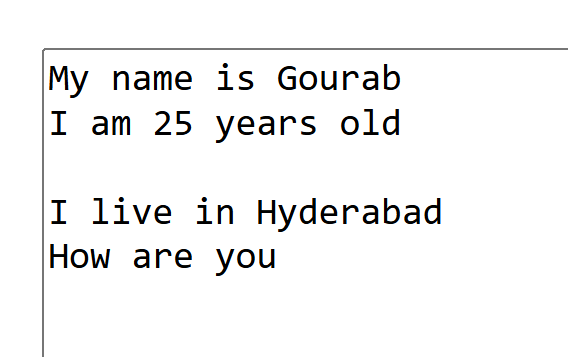
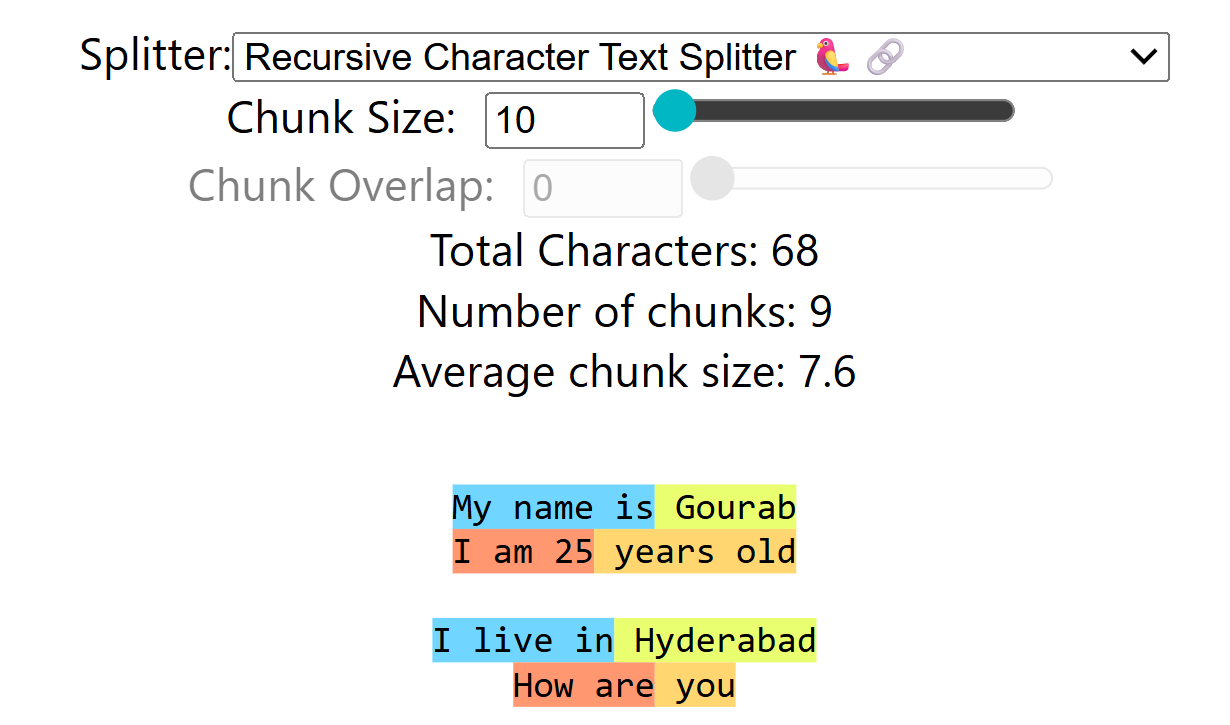

## Case 2: Chunk Size = 25

### What Happens?

- Paragraphs too large → split into sentences
- Sentences fit within limit
- No need to go to word level

### Final Chunks

- `My name is Gourab`
- `I am 25 years old`
- `I live in Hyderabad`
- `How are you`

### Key Observation

- Each chunk is a **complete sentence**
- Much better semantic clarity

---

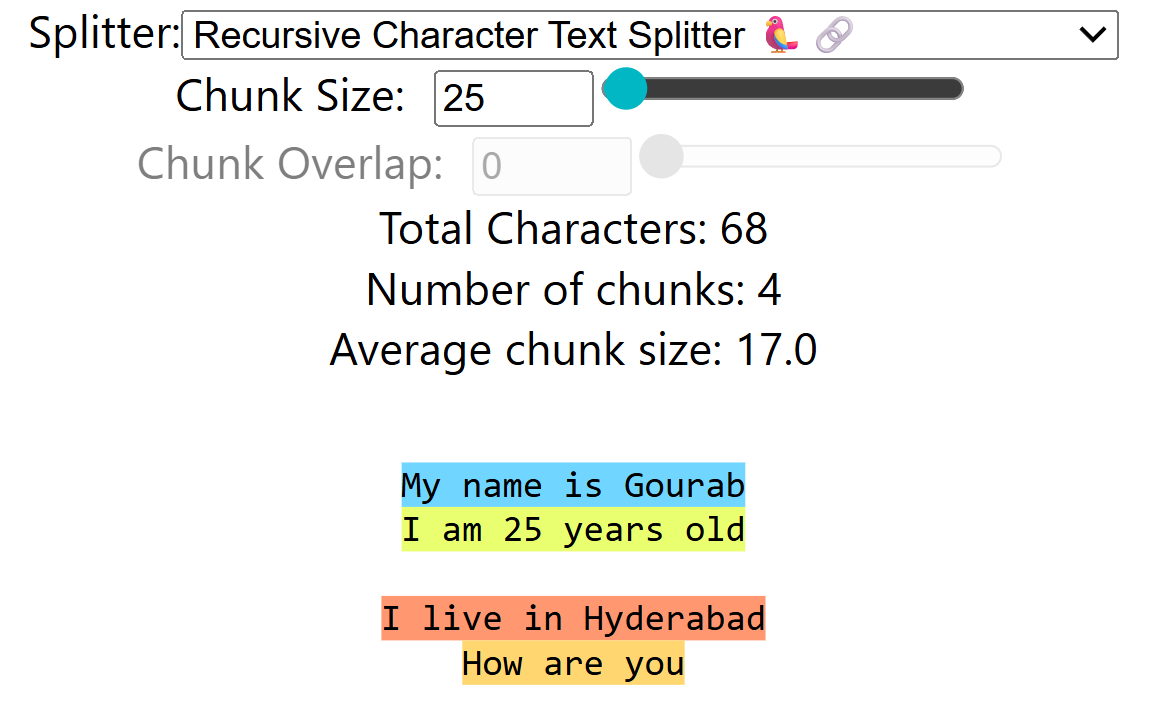

## Case 3: Chunk Size = 50

### What Happens?

- Paragraphs themselves fit
- No further splitting needed

### Final Chunks

- First paragraph
- Second paragraph

### Key Observation

- Structure is fully preserved
- Best possible semantic chunks

---

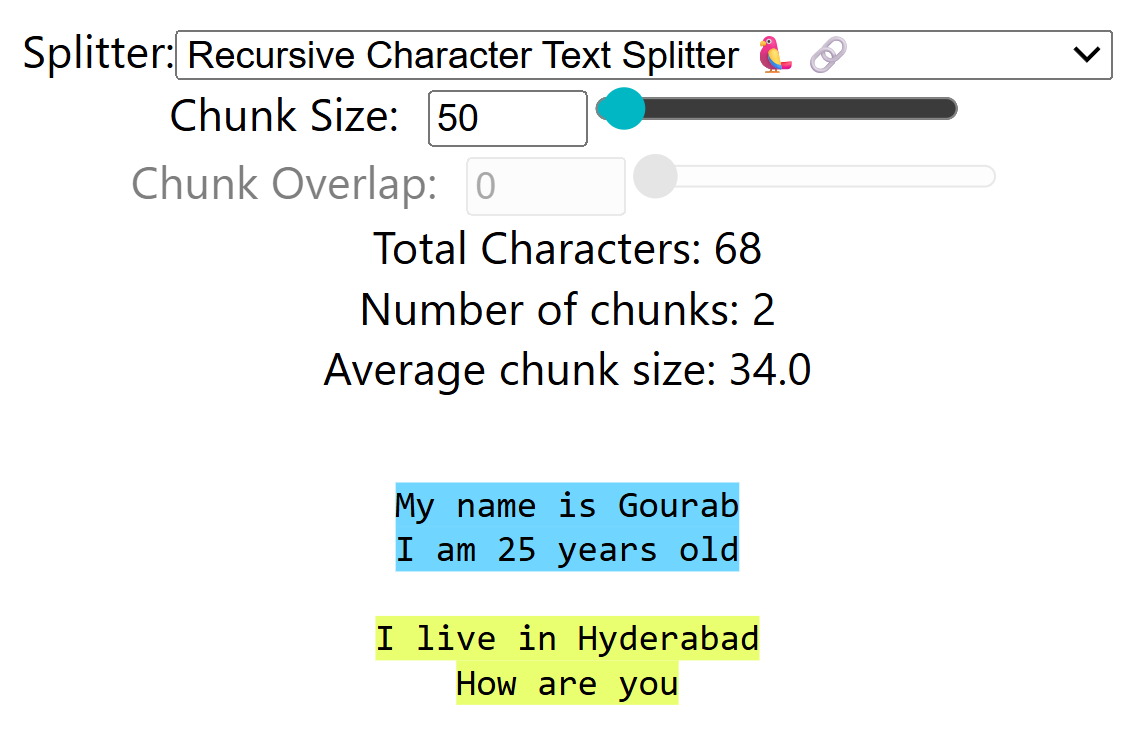

## Why This Is Better Than Character Splitting

### Character-Based Splitting
- Cuts words
- Cuts sentences
- Loses meaning
- Poor embeddings

### Recursive Character Splitting
- Preserves paragraphs when possible
- Preserves sentences when possible
- Preserves words when possible
- Falls back to characters only as a last resort

---

## Key Insight

As **chunk size increases**:
- Splitter prefers **paragraph-level chunks**

As **chunk size decreases**:
- Falls back to **sentence → word → character**

This adaptive behavior is what makes it powerful.

---

## When Should You Use This Splitter?

Use Recursive Character Text Splitting when:
- You are building RAG systems
- Semantic meaning matters
- Documents have natural structure
- You want a balance of performance + quality

---

## Why It Is So Popular in LangChain

- Structure-aware
- Safe defaults
- Works well across most document types
- Produces high-quality embeddings
- Minimal manual tuning required

---

## Final Takeaway

Recursive Character Text Splitting:
- Understands **how text is written**
- Adapts automatically to chunk size
- Preserves meaning far better than naive methods

This is why it is often the **default choice** in real-world LangChain applications.

In [4]:
from langchain.text_splitter import RecursiveCharacterTextSplitter

text = """
            Space exploration has led to incredible scientific discoveries. 
            From landing on the Moon to exploring Mars, humanity continues to push the boundaries of what’s possible beyond our planet.
            
            These missions have not only expanded our knowledge of the universe but have also contributed to advancements in technology here on Earth.
            Satellite communications, GPS, and even certain medical imaging techniques trace their roots back to innovations driven by space programs.
            """

# Initialize the splitter
splitter = RecursiveCharacterTextSplitter(
    chunk_size=100,
    chunk_overlap=0,
)

# Perform the split
chunks = splitter.split_text(text)

In [5]:
print(len(chunks))

7


In [6]:
print(chunks)

['Space exploration has led to incredible scientific discoveries.', 'From landing on the Moon to exploring Mars, humanity continues to push the boundaries', 'of what’s possible beyond our planet.', 'These missions have not only expanded our knowledge of the universe but have also', 'contributed to advancements in technology here on Earth.', 'Satellite communications, GPS, and even certain medical imaging techniques trace their', 'roots back to innovations driven by space programs.']


## Document-Based Text Splitting  
### (Structure-Aware Splitting for Non-Plain Text Documents)

### Why Do We Need Document-Based Text Splitters?

So far, we have discussed:
- **Length-based text splitting**
- **Text structure–based splitting** (paragraphs → sentences → words → characters)

These work well **only for plain natural language text** (English, Hindi, etc.).

But **not all documents are plain text**.

Examples of non-plain-text documents:
- Source code (Python, Java, etc.)
- Markdown files
- HTML
- PDFs with structured layouts

These documents:
- Are not organized into paragraphs and sentences
- Follow their **own syntax and constructs**

So applying normal text splitters directly would break their meaning.

---

## Core Idea of Document-Based Text Splitting

Document-based text splitting:
- Uses the **native structure of the document**
- Splits text based on **domain-specific constructs**
- Still uses the **recursive character splitting logic underneath**

In short:
> It is an **extension of recursive character text splitting**, customized for specific document types.

---

## Key Insight

The **algorithm remains the same**, but  
the **separators change depending on the document type**.

---

## Example 1: Code-Based Text Splitting (Python)

### Why Plain Text Splitting Fails for Code

Code is not structured as:
- Paragraphs
- Sentences

Instead, it is structured using:
- `class`
- `def`
- Loops
- Conditional blocks
- Indentation

So splitting code by paragraphs or sentences makes no sense.

---

### How Code-Based Splitting Works

For Python code, the splitter may use separators like:
- `class`
- `def`
- Other code-level keywords

After these separators are applied:
- If chunks are still too large,  
  it **falls back** to:
  - Line breaks
  - Words
  - Characters

So the hierarchy becomes:

1. Code constructs (`class`, `def`)
2. Lines
3. Words
4. Characters

---

### Result

- Entire class definitions stay together
- Individual methods become separate chunks
- Usage code (`object creation`, `if-else`) forms separate chunks

This preserves **logical boundaries in code**, which is critical for:
- Code understanding
- Code summarization
- Code-based RAG systems

---

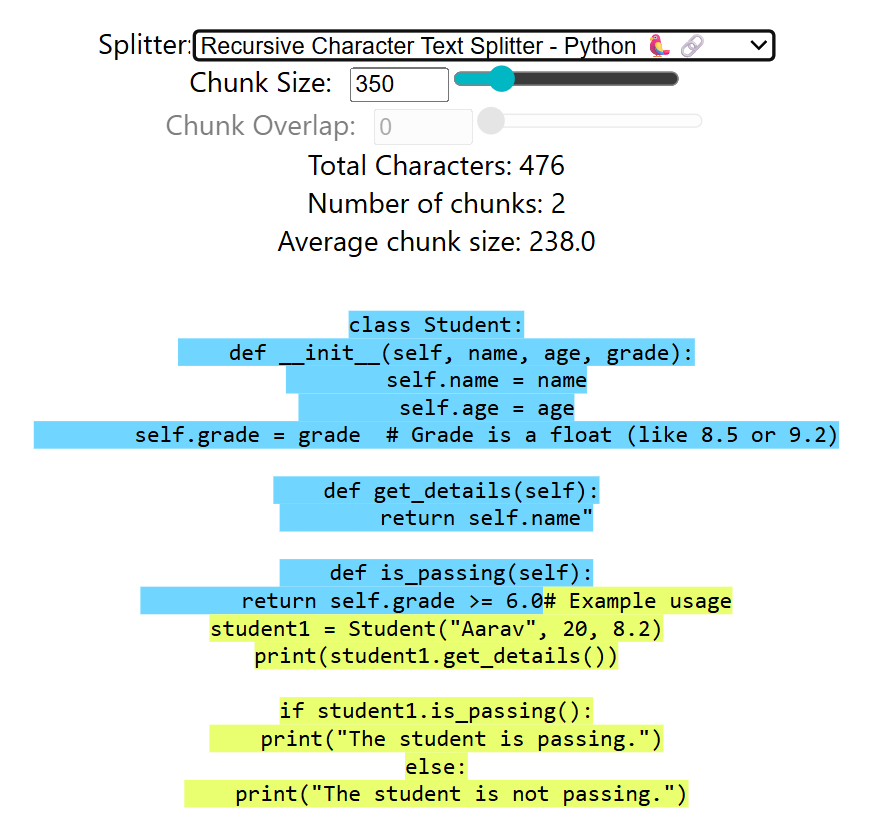

In [1]:
from langchain.text_splitter import RecursiveCharacterTextSplitter,Language

text = """
class Student:
    def __init__(self, name, age, grade):
        self.name = name
        self.age = age
        self.grade = grade  # Grade is a float (like 8.5 or 9.2)

    def get_details(self):
        return self.name"

    def is_passing(self):
        return self.grade >= 6.0


# Example usage
student1 = Student("Aarav", 20, 8.2)
print(student1.get_details())

if student1.is_passing():
    print("The student is passing.")
else:
    print("The student is not passing.")

"""

# Initialize the splitter
splitter = RecursiveCharacterTextSplitter.from_language(
    language=Language.PYTHON,
    chunk_size=350,
    chunk_overlap=0,
)

# Perform the split
chunks = splitter.split_text(text)

print(len(chunks))
print(chunks[1])

2
# Example usage
student1 = Student("Aarav", 20, 8.2)
print(student1.get_details())

if student1.is_passing():
    print("The student is passing.")
else:
    print("The student is not passing.")


## Example 2: Markdown-Based Text Splitting

### Why Markdown Needs Special Handling

Markdown is:
- Not a natural language
- A **markup language**

It organizes text using:
- Headings (`#`, `##`)
- Lists
- Sections
- Code blocks

So sentence-based splitting does not respect Markdown structure.

---

### How Markdown Splitting Works

Markdown splitters use separators like:
- Headings
- Section boundaries
- Markdown-specific syntax

Behind the scenes:
- Recursive character text splitting is still used
- But with **Markdown-aware separators**

---

### Practical Observation (Chunk Size Matters)

- Small chunk size → too many illogical chunks
- Increasing chunk size gradually:
  - First aligns with sub-sections
  - Then aligns perfectly with top-level sections

At the correct chunk size:
- Each Markdown section becomes **one clean chunk**
- Logical document flow is preserved

---

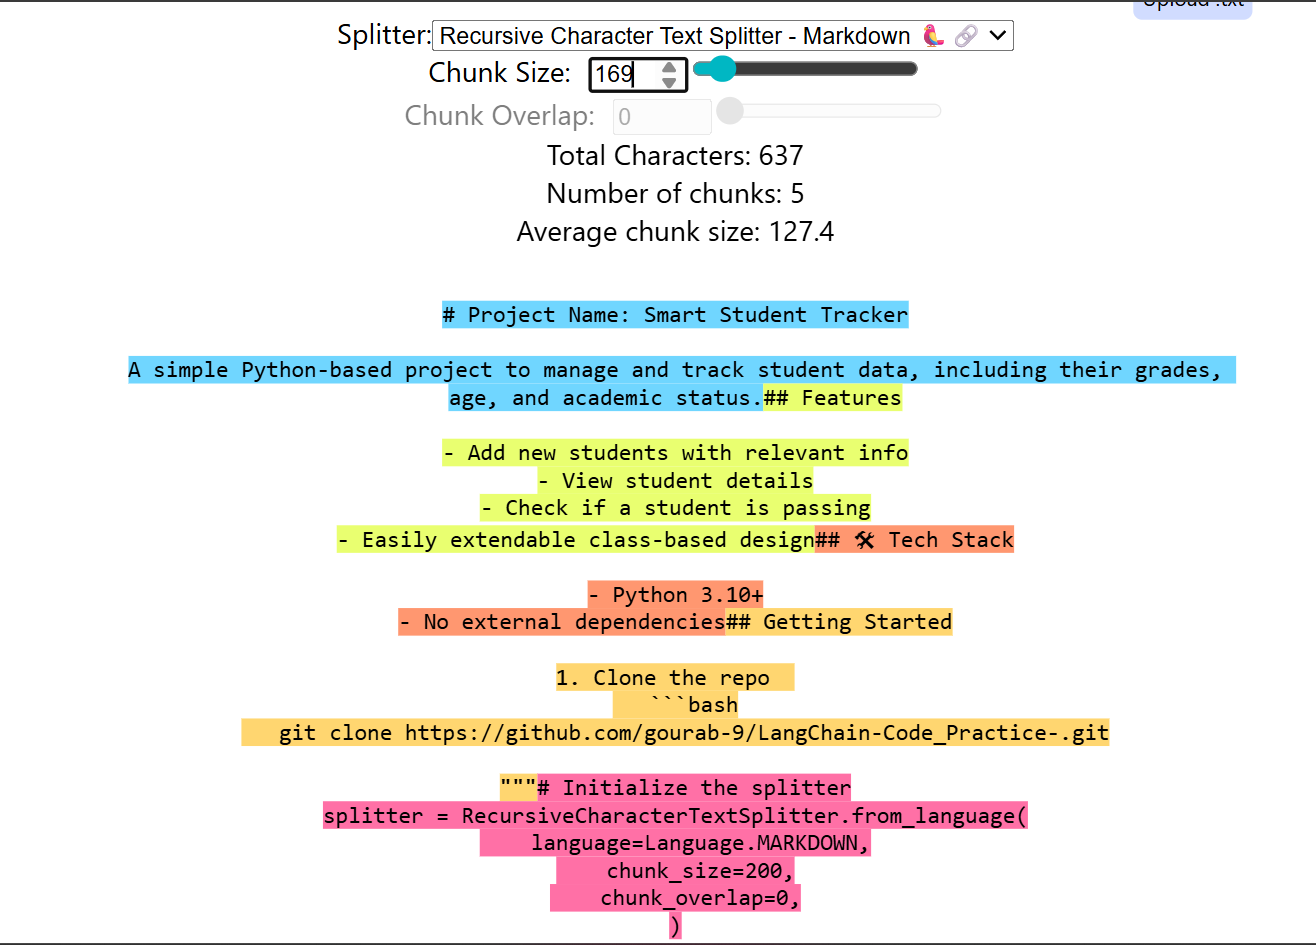

In [3]:
from langchain.text_splitter import RecursiveCharacterTextSplitter,Language

text = """
# Project Name: Smart Student Tracker

A simple Python-based project to manage and track student data, including their grades, age, and academic status.


## Features

- Add new students with relevant info
- View student details
- Check if a student is passing
- Easily extendable class-based design


## 🛠 Tech Stack

- Python 3.10+
- No external dependencies


## Getting Started

1. Clone the repo  
   ```bash
   git clone https://github.com/gourab-9/LangChain-Code_Practice-.git

"""

# Initialize the splitter
splitter = RecursiveCharacterTextSplitter.from_language(
    language=Language.MARKDOWN,
    chunk_size=169,
    chunk_overlap=0,
)

# Perform the split
chunks = splitter.split_text(text)

print(len(chunks))
print(chunks[0])

4
# Project Name: Smart Student Tracker

A simple Python-based project to manage and track student data, including their grades, age, and academic status.


## Example 3: Other Structured Documents

The same idea applies to:
- HTML documents
- PDF-extracted structured text
- Any domain-specific format

For each:
- You define or use **appropriate separators**
- Recursive splitting handles the rest

---

## What Is Happening Behind the Scenes?

No new algorithm is introduced.

Behind the scenes:
- **Recursive Character Text Splitter** is still running
- Only the **separator list is customized**

This makes the approach:
- Flexible
- Extensible
- Extremely powerful

---

## When Should You Use Document-Based Text Splitting?

Use it when:
- Your document is not plain language
- Structure matters more than raw text length
- You are working with:
  - Code
  - Markdown
  - HTML
  - Structured PDFs

---

## Final Takeaway

- Text structure–based splitting works for **natural language**
- Document-based splitting is its **logical extension**
- Same algorithm, different separators
- Preserves meaning, logic, and structure

This is essential for building **high-quality LLM and RAG applications** on real-world documents.

## Semantic Meaning–Based Text Splitting  
### (Meaning-Aware Text Chunking)

So far, we have learned **two major approaches** for text splitting:

1. **Length-based splitting**
   - Based on character count or token count
   - Very fast and simple
   - Does not care about meaning or structure

2. **Structure-based splitting**
   - Based on how text is organized:
     - Paragraphs
     - Sentences
     - Words
     - Characters
   - Example: Recursive Character Text Splitter

These approaches work well in many cases, **but not always**.

---

## Where Length-Based and Structure-Based Splitting Fail

There are certain scenarios where:
- Paragraph structure is misleading
- A single paragraph contains **multiple unrelated topics**

### Example Scenario

Imagine a text where:
- Paragraph 1 talks about **Agriculture and Farmers**
- Then suddenly switches to **IPL (Cricket)**
- Paragraph 2 talks about **Terrorism**

Visually, it looks like:
- Two paragraphs  
But semantically, it contains **three distinct topics**.

---

## Problem with Structure-Based Splitting

If we use a structure-based splitter:
- It will likely split the text into **two chunks**
  - Chunk 1 → Entire first paragraph
  - Chunk 2 → Second paragraph

### Why This Is a Problem

- Chunk 1 contains **two completely different topics**
- When embeddings are generated:
  - Semantic meaning gets mixed
  - Embedding quality becomes poor
- This negatively impacts:
  - Semantic search
  - Retrieval quality
  - RAG performance

---

## What *Should* Ideally Happen?

The ideal chunking would be:
1. Agriculture-related text → Chunk 1
2. IPL-related text → Chunk 2
3. Terrorism-related text → Chunk 3

This is **not possible** using only:
- Length-based rules
- Text structure rules

---

## Semantic Meaning–Based Text Splitting

This is where **semantic meaning–based text splitting** helps.

### Core Idea

Instead of deciding split points based on:
- Length
- Paragraphs
- Sentences

We decide split points based on:
- **Change in meaning**
- **Topic shift**

---

## How Semantic Text Splitters Work

### Step-by-Step Conceptual Flow

1. **Split text into sentences**
   - Each sentence becomes a small unit

2. **Generate embeddings for each sentence**
   - Using an embedding model (e.g., OpenAI embeddings)

3. **Compare embeddings of consecutive sentences**
   - Sentence 1 ↔ Sentence 2
   - Sentence 2 ↔ Sentence 3
   - Sentence 3 ↔ Sentence 4

4. **Calculate semantic similarity**
   - Usually using cosine similarity

---

## Key Observation

- If two sentences talk about the **same topic**  
  → Similarity score will be **high**
- If topic changes suddenly  
  → Similarity score will **drop sharply**

This sudden drop indicates:
> **A semantic boundary**

That boundary is where the text should be split.

---

## Sliding Window Approach

Semantic text splitters use a **sliding window** approach:

- Move sentence by sentence
- Compare meaning continuously
- Detect abrupt semantic changes
- Perform splitting at those points

---

## Why This Approach Is Powerful

- Preserves semantic coherence
- Ensures each chunk talks about **one topic**
- Produces high-quality embeddings
- Improves:
  - Semantic search accuracy
  - RAG response relevance
  - Context grounding

---

## Current Limitations

- Computationally expensive
  - Requires embedding generation for many sentences
- Slightly complex compared to other splitters
- Still **experimental** in many frameworks

---

## Status in LangChain

- Semantic meaning–based text splitters **do exist**
- They are currently marked as **experimental**
- Not widely used yet in production

---

## Future Outlook

As embedding models become:
- Faster
- Cheaper
- More accurate

Semantic text splitting is expected to:
- Become more common
- Replace heuristic-based splitting in many pipelines

---

## Final Takeaway

- Length-based splitting → Fast but shallow
- Structure-based splitting → Better but still limited
- Semantic meaning–based splitting → Most accurate, topic-aware

This approach represents the **next evolution** of text splitting for high-quality LLM and RAG systems.


In [1]:
from langchain_experimental.text_splitter import SemanticChunker
from langchain_openai.embeddings import OpenAIEmbeddings
from dotenv import load_dotenv
import os


load_dotenv(override=True)
api_key = os.getenv("OPENAI_API_KEY")

text_splitter = SemanticChunker(
    OpenAIEmbeddings(api_key=api_key), breakpoint_threshold_type="standard_deviation",
    breakpoint_threshold_amount=3
)

sample = """
        Farmers were working hard in the fields, preparing the soil and planting seeds for the next season. 
        The sun was bright, and the air smelled of earth and fresh grass. 
        The Indian Premier League (IPL) is the biggest cricket league in the world. 
        People all over the world watch the matches and cheer for their favourite teams.
        
        
        Terrorism is a big danger to peace and safety. 
        It causes harm to people and creates fear in cities and villages. 
        When such attacks happen, they leave behind pain and sadness. 
        To fight terrorism, we need strong laws, alert security forces, and support from people who care about peace and safety.
        """

docs = text_splitter.create_documents([sample])
print(len(docs))
print(docs)


1
[Document(metadata={}, page_content='\n        Farmers were working hard in the fields, preparing the soil and planting seeds for the next season. The sun was bright, and the air smelled of earth and fresh grass. The Indian Premier League (IPL) is the biggest cricket league in the world. People all over the world watch the matches and cheer for their favourite teams. Terrorism is a big danger to peace and safety. It causes harm to people and creates fear in cities and villages. When such attacks happen, they leave behind pain and sadness. To fight terrorism, we need strong laws, alert security forces, and support from people who care about peace and safety. ')]
